In [1]:
from IPython.display import clear_output
!pip install pandas
!pip install numpy
!pip install tensorflow
!pip install seaborn
clear_output()

## Multiplicación de matrices

Debido a la facilidad, y partiendo de las bases creadas en el taller anterior, se desarrollo un modelo de multiplicación matricial 2x2, con valores continuos entre -20 y 20, con la ayuda de pandas y tensorflow

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf

I0000 00:00:1773505842.385744   80167 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Dataframe
El primer paso es poblar un dataframe de tamaño 62500 (80% entrenamiento-50000 y 20% Validación-12500) con valores aleatorios, luego de esto, se realiza la multiplicación para cada elemento de la matriz resultante **R**

In [3]:
a11=np.random.random(62500)*40-20
a12=np.random.random(62500)*40-20
a21=np.random.random(62500)*40-20
a22=np.random.random(62500)*40-20

b11=np.random.random(62500)*40-20
b12=np.random.random(62500)*40-20
b21=np.random.random(62500)*40-20
b22=np.random.random(62500)*40-20


df=pd.DataFrame({   'a11':a11,
                    'a12':a12,
                    'a21':a21,
                    'a22':a22,
                    'b11':b11,
                    'b12':b12,
                    'b21':b21,
                    'b22':b22,
                    })

print(len(df),len(df.drop_duplicates()))

df['R11']=(df['a11']*df['b11'])+(df['a12']*df['b21'])
df['R12']=(df['a11']*df['b12'])+(df['a12']*df['b22'])
df['R21']=(df['a21']*df['b11'])+(df['a22']*df['b21'])
df['R22']=(df['a21']*df['b12'])+(df['a22']*df['b22'])

df_train=df[:50000]
df_test=df[50000:56250]
df_test_2=df[56250:]

print(len(df_train), len(df_test))

df.head()

62500 62500
50000 6250


,a11,a12,a21,a22,b11,b12,b21,b22,R11,R12,R21,R22
0,-19.859357,5.799481,17.714509,14.468604,-14.237828,1.367443,2.735435,-10.984946,298.618213,-90.863517,-212.638203,-134.713254
1,2.065245,9.519398,7.929935,15.284411,13.447387,-10.804133,-5.233030,13.128478,-22.043152,102.662033,26.653124,114.984985
2,6.781121,-16.743240,-5.802747,5.866607,-16.357056,4.456763,-3.906399,-10.738794,-45.513398,210.024060,71.998550,-88.861749
3,-7.810563,13.307536,-6.688513,-7.069813,-10.423871,-10.510279,14.818595,-3.592499,278.615295,34.283882,-35.044492,95.696442
4,-6.556643,-1.913783,-0.091864,-13.926956,3.408023,12.076017,2.043544,7.544073,-26.256086,-93.615843,-28.773428,-106.175330


### Definición del modelo

Para la definición del modelo, se selecciónan las columnas que haran parte de las entradas y las columnas correspondientes a la salida, en este caso, es un modelo con 8 entradas (correspondientes a 2 veces el tamaño de una matriz) y una salida de tamaño 4 (una vez el tamaño de la matriz), en el medio, se usa una capa con mayor densidad de neuronas, para converger mas rapido al resultado

In [4]:
salidas=['R11','R12','R21','R22']
entradas=['a11', 'a12', 'a21', 'a22', 'b11', 'b12', 'b21', 'b22']
tamaño=len(entradas)

x=[]

for i in entradas:
    x.append(df_train[i])

X=np.column_stack(x)

y=[]

for i in salidas:
    y.append(df_train[i])

Y=np.column_stack(y)

entrada = tf.keras.layers.Dense(units=tamaño, input_shape=[tamaño], activation="relu")
c1 = tf.keras.layers.Dense(units=64, activation="relu")
c2 = tf.keras.layers.Dense(units=64, activation="relu")
c3 = tf.keras.layers.Dense(units=32, activation="relu")
c4 = tf.keras.layers.Dense(units=16, activation="relu")
c5 = tf.keras.layers.Dense(units=8, activation="relu")
c6 = tf.keras.layers.Dense(units=8, activation="relu")
salida = tf.keras.layers.Dense(units=4, activation="linear")
#red = tf.keras.Sequential([entrada, c1, salida])
red = tf.keras.Sequential([entrada, c1, c2,c3,c4, c5, c6, salida])
red.compile(optimizer='adam',
            loss="mse",
            metrics=['accuracy'])

/home/robotica/Jupyter_lab/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773505848.372227   80167 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Se realiza el entrenamiento del modelo, al tener muchas capas, se usa una corta cantidad de epocas pues el modelo converge mas rapido, **para mejorar el tiempo de ejecución, se comenta el entrenamieno y se carga el modelo preentrenado, sin embargo descomentando las dos lineas de codigo adicionales y comentando la carga del modelo se puede volver a entrenar el modelo.**

In [5]:
red= tf.keras.models.load_model("Dense_model.keras")
#historial = red.fit(X, Y, epochs=600, verbose=False)
#red.save("Dense_model.keras")

### Verificación del modelo

Ahora, se evalua la capacidad del modelo, con la ayuda del dataframe de validación, en el cual se añaden las columnas correspondientes a los 4 valores predichos por el modelo.

In [6]:
def clasificar_dataframe(df, modelo, columnas, salidas):
    X = df[columnas].values
    preds = modelo.predict(X)

    for i in range(len(salidas)):
        df[salidas[i]] = preds[:,i]
#    df['R11_a'] = preds[:,0]
    #df['Predeccion']=(preds > 0.5).astype(int)
    return df

salidas_2 = []
errores= []
for i in salidas:
    salidas_2.append(f'{i}_pred')
    errores.append(f'{i}_error')

clasificar_dataframe(df_test, red, entradas, salidas_2)

196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,a11,a12,a21,a22,b11,b12,b21,b22,R11,R12,R21,R22,R11_pred,R12_pred,R21_pred,R22_pred
50000,-0.050695,-0.779071,-13.767182,-17.131910,10.247134,-15.705126,-19.829551,-14.899204,14.929148,12.403700,198.643925,471.467159,18.881786,8.568127,196.641815,470.695557
50001,-5.394470,-19.580546,-8.655875,10.394969,2.203568,1.013497,15.663375,4.514394,-318.584519,-93.861582,143.746493,38.154280,-325.642120,-95.244385,141.661575,36.781693
50002,6.027857,-10.965340,13.020033,-15.808806,-6.593877,-14.823678,14.288989,0.120052,-196.430572,-90.671421,-311.744347,-194.902652,-190.292511,-89.906631,-317.125580,-196.745834
50003,6.719994,0.378839,-0.393847,-18.252012,7.987476,-6.913121,-13.749690,-2.633301,48.466863,-47.453728,247.813667,50.785764,45.619564,-45.462376,246.628311,44.741165
50004,17.808923,18.970924,-5.157838,16.562767,-17.296919,-8.188786,17.303076,16.760840,20.215859,172.135169,375.801530,319.842324,-0.575691,164.120926,378.148163,323.698120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56245,-1.166426,15.334349,12.483581,10.724532,16.499204,12.856760,16.838383,-13.392867,238.960544,-220.367354,386.552941,16.866173,232.850555,-222.743332,373.669037,16.496765
56246,13.001940,-15.627797,8.166449,-13.765574,-10.076268,9.204236,-6.639541,-10.925737,-27.249626,290.418117,9.109768,225.564965,-28.567095,291.328247,1.928393,224.648834
56247,16.398832,-17.111463,7.603102,19.943748,16.866325,19.161753,14.575021,8.793974,27.188102,163.752611,418.916943,321.073565,18.902977,166.004700,418.653534,327.737976
56248,-17.361119,3.036996,5.479328,16.585458,-11.781464,-15.428335,-16.241070,6.764040,155.215348,288.395519,-333.920100,27.647794,142.666794,285.253571,-347.317719,25.201239


Se evalua el error absoluto para cada elemento del resultado y se promedia el error obtenido para toda la matriz, **El dataframe presentado en la siguiente casilla, esta ordenado de forma descendente por el mayor error medio para el conjunto, es decir que se presentan los peores resultados**, con esto en mente, es notable que en la mayoria de los casos, el mayor error presentado es debido a que el modelo se equivoca en la predicción de los valores muy pequeños, generando una alta desviación, y es notable, que el el valor nro 100 mas alto corresponda a 617%, lo que ubica a los restantes 12400 como mejores evaluaciones de la multiplicación de matrices.

In [7]:
for i in zip(salidas, salidas_2, errores):
    df_test[i[2]]=np.abs((df_test[i[0]]-df_test[i[1]])/df_test[i[0]])*100
    
df_test['error_media'] = df_test[errores].mean(axis=1)

df_test[salidas+salidas_2+errores+['error_media']].sort_values(by='error_media', ascending=False).round(2).head(100)

,R11,R12,R21,R22,R11_pred,R12_pred,R21_pred,R22_pred,R11_error,R12_error,R21_error,R22_error,error_media
53544,76.36,28.11,0.00,37.00,78.290001,23.270000,-2.930000,33.410000,2.53,17.23,438558.27,9.70,109646.93
54524,105.37,500.86,0.01,-374.79,103.769997,498.709991,-5.910000,-374.709991,1.51,0.43,105113.35,0.02,26278.83
53269,-61.53,0.02,-53.13,213.67,-62.200001,-4.760000,-59.040001,209.009995,1.10,23330.55,11.12,2.18,5836.23
51263,-0.02,52.82,90.28,-84.47,2.490000,52.209999,86.669998,-88.599998,11639.72,1.16,3.99,4.89,2912.44
50668,4.94,133.43,-0.05,-156.47,0.140000,132.380005,-4.300000,-156.550003,97.22,0.78,8941.95,0.05,2260.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50648,-143.44,391.27,-272.89,0.99,-146.389999,384.309998,-277.059998,-4.340000,2.05,1.78,1.53,540.17,136.38
56141,78.00,221.09,-3.37,0.91,71.360001,221.970001,-2.290000,-3.700000,8.52,0.40,32.08,504.30,136.32
52528,-66.71,-24.44,28.21,0.52,-63.820000,-25.320000,25.700001,-2.230000,4.34,3.56,8.89,526.69,135.87
54263,49.41,-1.33,110.17,-72.99,42.820000,-8.250000,112.080002,-69.519997,13.35,518.22,1.73,4.75,134.51


### Representación grafica de la distribución del error

Por ultimo, se presentan las graficas para cada componente, donde se observa un comportamiento logaritmico, con una alta concentración de errores inferior al **4%**, y la mayor parte de la población con errores de menos del 100%, lo cual es notable, dado a la cantidad de neuronas usadas.

Es interesante, comparar las ventajas de las 2 aproximaciones posibles:
 - **Muchas capas densas y poco entrenamiento:** Ofrece un modelo el cual converge al resultado en menos tiempo, pero con un mayor coste computacional debido al tamaño del modelo.
 - **Pocas capas con entrenamiento extenso:** Ofrece resultados similares (de menor calidad), aunque el coste de entrenamiento es mucho mas alto, la eficiencia del modelo durante la evaluación mejora al requerir menos recursos.

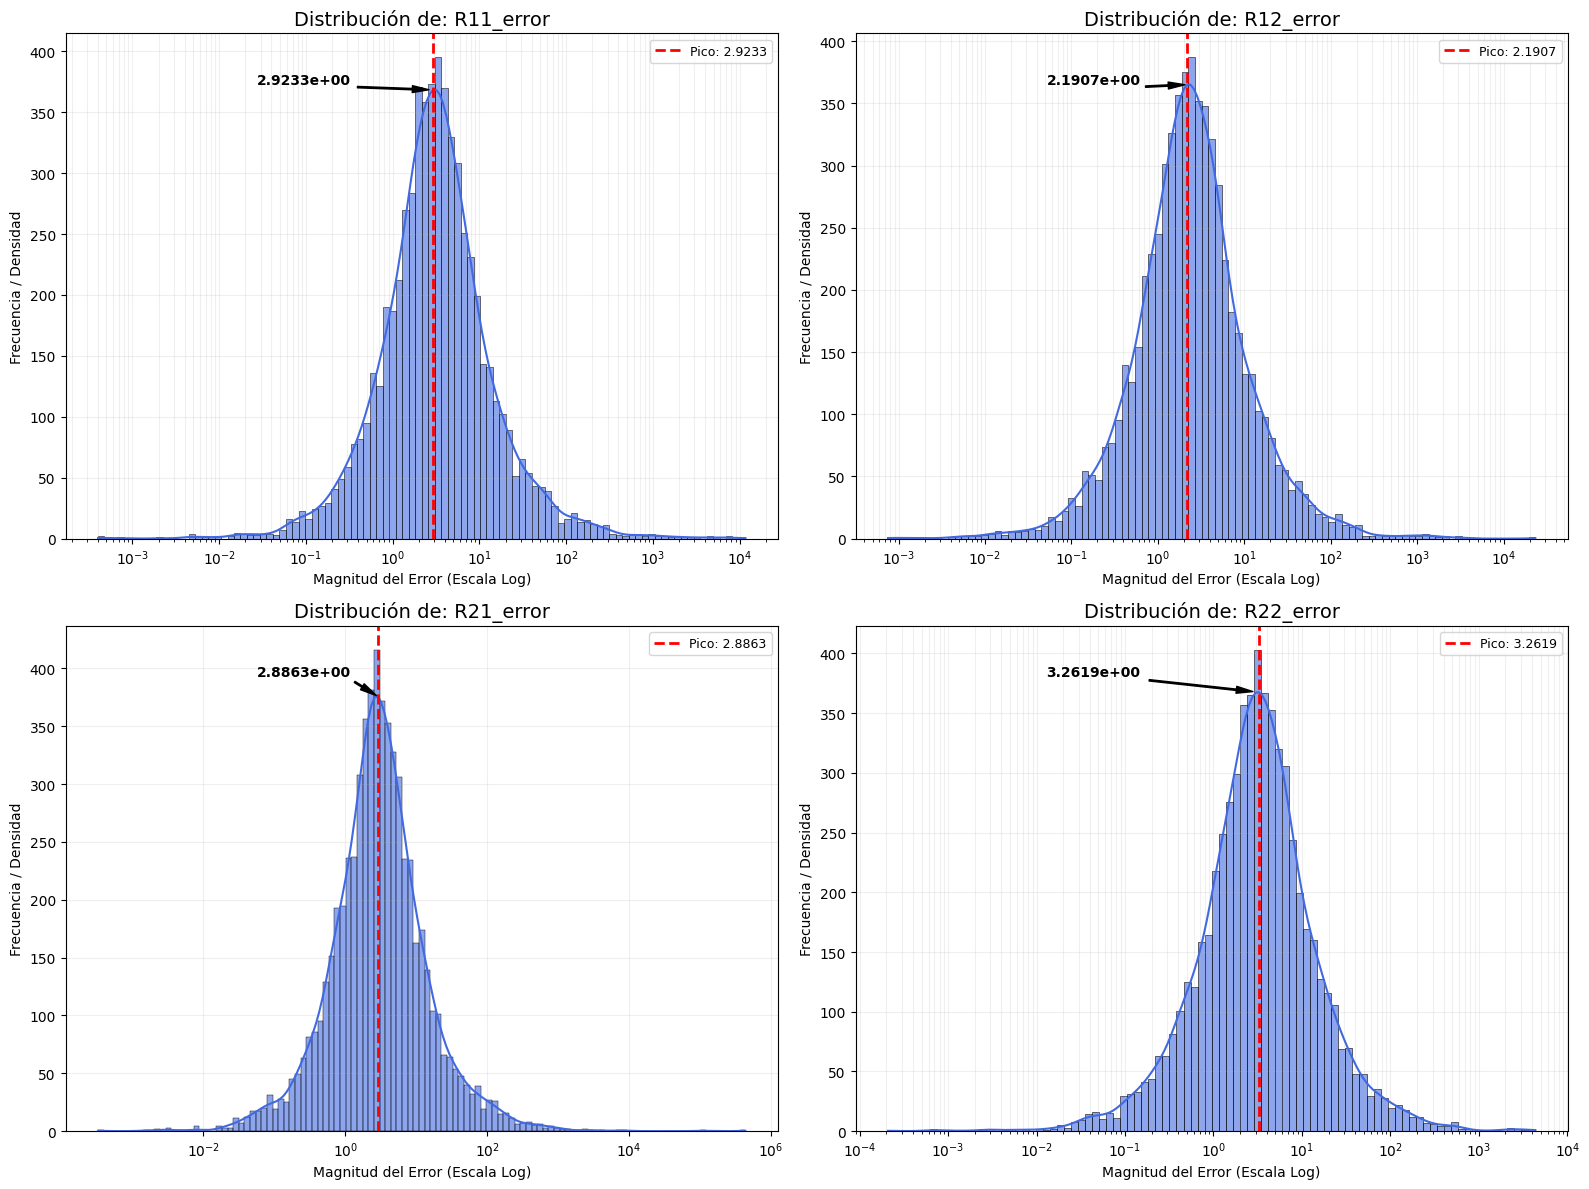

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Define aquí los nombres de tus 4 columnas de error

# 2. Configurar la cuadrícula (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Convertimos la matriz 2x2 en una lista plana para iterar fácil

for i, col in enumerate(errores):
    ax = axes[i]
    
    # Crear el histplot en el eje correspondiente (ax)
    sns.histplot(df_test[col], kde=True, log_scale=True, color='royalblue', alpha=0.6, ax=ax)
    
    # Extraer los datos de la curva KDE
    if len(ax.lines) > 0:
        line = ax.lines[0]
        x, y = line.get_data()
        
        # Encontrar el pico de concentración
        idx_max = np.argmax(y)
        pico_error = x[idx_max]
        
        # Indicación visual
        ax.axvline(pico_error, color='red', linestyle='--', lw=2, label=f'Pico: {pico_error:.4f}')
        
        # Anotación (ajustada para escala log)
        ax.annotate(f'{pico_error:.4e}', 
                     xy=(pico_error, y[idx_max]), 
                     xytext=(0.4, 0.9), textcoords='axes fraction', # Posición relativa al subplot
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                     fontsize=10, fontweight='bold', horizontalalignment='right')

    # Personalización de cada subplot
    ax.set_title(f'Distribución de: {col}', fontsize=14)
    ax.set_xlabel('Magnitud del Error (Escala Log)')
    ax.set_ylabel('Frecuencia / Densidad')
    #ax.set_xlim([0,100])
    ax.legend(fontsize=9)
    ax.grid(True, which="both", ls="-", alpha=0.2)

# Ajustar espacio entre gráficas para que no se encimen los títulos
plt.tight_layout()
plt.show()